In [14]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

In [15]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [17]:
df = pd.read_csv("Instagram visits clustering.csv")
df.head()

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


In [18]:
x = df.drop(columns=["User ID"])

In [19]:
num_cols=df.select_dtypes(include='number').columns

In [20]:
preprocessing=ColumnTransformer(
    transformers=[
        ('scaling',StandardScaler(),num_cols)])

main_pipeline=Pipeline(
    steps=[
        ('pre',preprocessing),
        ('model',KMeans(n_clusters=2,random_state=42))
         ])

In [21]:
main_pipeline.fit_predict(df)
main_pipeline.fit_transform(df)

  File "c:\Users\AVANIY\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\AVANIY\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\AVANIY\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1036, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
             

array([[1.71962634, 2.55058014],
       [1.72268557, 2.52204389],
       [2.30586424, 3.09038135],
       ...,
       [3.13513756, 2.20342088],
       [1.96206189, 2.75413395],
       [2.80768431, 2.04082138]], shape=(2600, 2))

Elbow Method

In [22]:
import matplotlib.pyplot as plt
metrics_=[]
for cluster in range(1,10):
    pipeline=Pipeline(
    steps=[
        ('pre',preprocessing),
        ('model',KMeans(n_clusters=cluster,random_state=42))  #8 default cluster
         ])
    model=KMeans(n_clusters=cluster)
    pipeline.fit(df)
    inertia = pipeline.named_steps["model"].inertia_    #inertia stored in model
    metrics_.append(inertia)
    

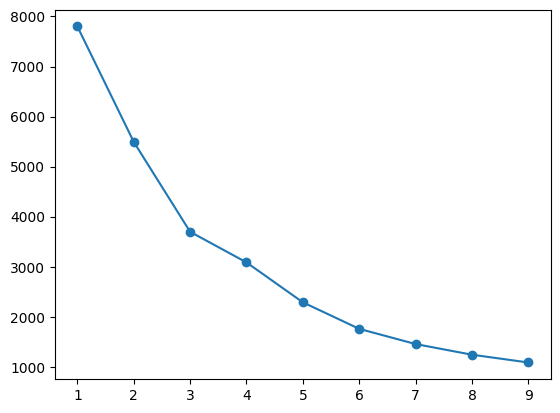

In [23]:
plt.plot(range(1,10),metrics_,marker='o')       #where curve is bending best cluster

In [24]:
main_pipeline=Pipeline(
    steps=[
        ('pre',preprocessing),
        ('model',KMeans(n_clusters=4,random_state=42))  #8 default cluster
         ])          #at 4 graph is bended so n_clusters=4

In [25]:
labels = pipeline.fit_predict(df)

PCA

In [26]:
from sklearn.decomposition import PCA

updated_df = preprocessing.fit_transform(df)
pca=PCA(n_components=2)           #2 
pca_data=pca.fit_transform(updated_df)

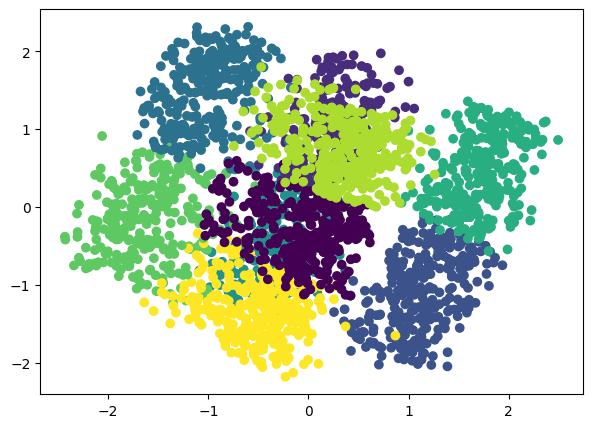

In [27]:
plt.figure(figsize=(7,5))
plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=labels,
)

Conclusion: K-Means clustering was applied to segment customers based on their Instagram visit score and spending rank. The Elbow Method indicated that 4 clusters is the optimal choice. The algorithm successfully grouped customers with similar behavior, allowing the identification of different customer segments. These segments can help businesses design targeted marketing campaigns, improve customer engagement, and make data-driven business decisions.